In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
from upsetplot import UpSet
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
dftis = pd.read_csv(f'{path}/../tissue40.list', sep='\t')
tislist = list(dftis['Tissue'])
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/sheepGTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [5]:
color_dict = {
    'eQTL vs. eeQTL': '#FFC300',
    'eQTL vs. isoQTL': '#FF8D1A',
    'eQTL vs. enQTL': '#CD853F',
    'eQTL vs. sQTL': '#55A868',
    'eQTL vs. stQTL': '#3A5FCD',
    "eQTL vs. 3'aQTL": '#984EA3'}
color_dict1 = {
    '0': '#F6B48F',
    '1': '#F37651',
    '2': '#AD1759',
    '3': '#35193E'}

In [7]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
df_shared = pd.read_csv(f'{path}/eQTL.sig.list', sep='\t')
df_shared['Shared'] = 'Unique'
df_shared.loc[df_shared['snp1']==df_shared['snp2'], 'Shared'] = 'Shared'
# get significant lead variant in both QTLs 
df_sharedt = df_shared[(df_shared['is_eGene1']==True)&(df_shared['is_eGene2']==True)]
df_sharedt

,tissue,qtl1,qtl2,gene,snp1,snp2,is_eGene1,is_eGene2,Shared
7,Abomasum,eQTL,3aQTL,COPS9,1_1338893,1_1336721,True,True,Unique
8,Abomasum,eQTL,3aQTL,NDUFA10,1_1697199,1_1735653,True,True,Unique
30,Abomasum,eQTL,3aQTL,C1H1orf109,1_12502192,1_12474430,True,True,Unique
32,Abomasum,eQTL,3aQTL,UTP11,1_12763037,1_12764588,True,True,Unique
44,Abomasum,eQTL,3aQTL,C1H1orf50,1_17255650,1_17249900,True,True,Unique
...,...,...,...,...,...,...,...,...,...
729478,Uterus,eQTL,stQTL,BAG4,26_32474465,26_32521446,True,True,Unique
729481,Uterus,eQTL,stQTL,GOLGA7,26_35939849,26_35769771,True,True,Unique
729489,Uterus,eQTL,stQTL,HGSNAT,26_37125553,26_37115337,True,True,Unique
729490,Uterus,eQTL,stQTL,CSGALNACT1,26_37183545,26_37558082,True,True,Unique


In [8]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
df_ld = pd.read_csv(f'{path}/eQTL.r2', sep='\t')
df_ld = df_ld.groupby(['tissue','pairs','gene','snp1','snp2'])['r2'].max().reset_index()
df_shared['pairs'] = df_shared['qtl1'] + '_' + df_shared['qtl2']
df_ld = pd.merge(df_shared, df_ld, how='left', on=['tissue','pairs','gene','snp1','snp2'])
df_ld['Pairs'] = df_ld['pairs'].replace({'eQTL_sQTL':'eQTL vs. sQTL',
                    'eQTL_eeQTL':'eQTL vs. eeQTL',
                    'eQTL_isoQTL':'eQTL vs. isoQTL',
                    'eQTL_stQTL':'eQTL vs. stQTL',
                    'eQTL_3aQTL':"eQTL vs. 3'aQTL",
                    'eQTL_enQTL':"eQTL vs. enQTL"})
# get significant lead variant in both QTLs 
df_ldt = df_ld[(df_ld['is_eGene1']==True)&(df_ld['is_eGene2']==True)]
df_ldt

,tissue,qtl1,qtl2,gene,snp1,snp2,is_eGene1,is_eGene2,Shared,pairs,r2,Pairs
7,Abomasum,eQTL,3aQTL,COPS9,1_1338893,1_1336721,True,True,Unique,eQTL_3aQTL,0.289674,eQTL vs. 3'aQTL
8,Abomasum,eQTL,3aQTL,NDUFA10,1_1697199,1_1735653,True,True,Unique,eQTL_3aQTL,0.008618,eQTL vs. 3'aQTL
30,Abomasum,eQTL,3aQTL,C1H1orf109,1_12502192,1_12474430,True,True,Unique,eQTL_3aQTL,0.249645,eQTL vs. 3'aQTL
32,Abomasum,eQTL,3aQTL,UTP11,1_12763037,1_12764588,True,True,Unique,eQTL_3aQTL,0.076912,eQTL vs. 3'aQTL
44,Abomasum,eQTL,3aQTL,C1H1orf50,1_17255650,1_17249900,True,True,Unique,eQTL_3aQTL,0.033781,eQTL vs. 3'aQTL
...,...,...,...,...,...,...,...,...,...,...,...,...
729478,Uterus,eQTL,stQTL,BAG4,26_32474465,26_32521446,True,True,Unique,eQTL_stQTL,0.504351,eQTL vs. stQTL
729481,Uterus,eQTL,stQTL,GOLGA7,26_35939849,26_35769771,True,True,Unique,eQTL_stQTL,0.011286,eQTL vs. stQTL
729489,Uterus,eQTL,stQTL,HGSNAT,26_37125553,26_37115337,True,True,Unique,eQTL_stQTL,0.202838,eQTL vs. stQTL
729490,Uterus,eQTL,stQTL,CSGALNACT1,26_37183545,26_37558082,True,True,Unique,eQTL_stQTL,0.061363,eQTL vs. stQTL


# Fig. 3a

In [6]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
# get significant QTLs in both pairs
#df_pp4s = pd.read_csv(f'{path}/eQTL.addcol.sig.pph4', sep='\t')
#df_pp4t = pd.merge(df_pp4s, df_ldt, left_on=['tissue', 'qtl', 'phenotype1'], right_on=['tissue', 'qtl2', 'gene'])
#df_pp4t = pd.merge(df_pp4t, dftis, left_on='tissue', right_on="Tissue")
#df_pp4t.loc[df_pp4t['snp1']==df_pp4t['snp2'], 'r2'] = 1
#df_pp4t.to_csv(f'{path}/coloc_qtl.stat.sig.txt', sep="\t", index=False)
df_pp4t = pd.read_csv(f'{path}/coloc_qtl.stat.sig.txt', sep="\t")
df_pp4t

,qtl,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,phenotype1,phenotype2,chrom,...,snp2,is_eGene1,is_eGene2,Shared,pairs,r2,Pairs,Tissue,Sample size,PEER
0,3aQTL,4167,3.588298e-31,8.090776e-05,9.509926e-29,0.020463,0.979456,COPS9,XM_027978770.2|COPS9|chr1|+,chr1,...,1_1336721,True,True,Unique,eQTL_3aQTL,0.289674,eQTL vs. 3'aQTL,Abomasum,228,30
1,3aQTL,3099,3.378199e-07,4.525931e-07,4.156979e-01,0.556902,0.027399,NDUFA10,XM_004001759.4|NDUFA10|chr1|+,chr1,...,1_1735653,True,True,Unique,eQTL_3aQTL,0.008618,eQTL vs. 3'aQTL,Abomasum,228,30
2,3aQTL,2577,1.207184e-12,2.002849e-01,4.751139e-12,0.788254,0.011461,C1H1orf109,XM_042245762.1|C1H1orf109|chr1|-,chr1,...,1_12474430,True,True,Unique,eQTL_3aQTL,0.249645,eQTL vs. 3'aQTL,Abomasum,228,30
3,3aQTL,2577,3.381487e-12,5.610251e-01,2.432736e-12,0.403582,0.035393,C1H1orf109,XM_012099679.4|C1H1orf109|chr1|-,chr1,...,1_12474430,True,True,Unique,eQTL_3aQTL,0.249645,eQTL vs. 3'aQTL,Abomasum,228,30
4,3aQTL,3603,1.002800e-01,5.744902e-02,4.178357e-01,0.239187,0.185248,UTP11,XM_012100981.4|UTP11|chr1|+,chr1,...,1_12764588,True,True,Unique,eQTL_3aQTL,0.076912,eQTL vs. 3'aQTL,Abomasum,228,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421417,stQTL,3737,3.727566e-01,1.789679e-01,2.619506e-01,0.125707,0.060618,BAG4,BAG4,chr26,...,26_32521446,True,True,Unique,eQTL_stQTL,0.504351,eQTL vs. stQTL,Uterus,178,30
421418,stQTL,3611,1.616101e-01,9.672197e-02,4.356177e-01,0.260667,0.045383,GOLGA7,GOLGA7,chr26,...,26_35769771,True,True,Unique,eQTL_stQTL,0.011286,eQTL vs. stQTL,Uterus,178,30
421419,stQTL,5853,8.359989e-05,1.265090e-04,3.859646e-01,0.584038,0.029787,HGSNAT,HGSNAT,chr26,...,26_37115337,True,True,Unique,eQTL_stQTL,0.202838,eQTL vs. stQTL,Uterus,178,30
421420,stQTL,5737,4.583021e-04,1.047845e-03,1.045882e-01,0.238471,0.655435,CSGALNACT1,CSGALNACT1,chr26,...,26_37558082,True,True,Unique,eQTL_stQTL,0.061363,eQTL vs. stQTL,Uterus,178,30


In [28]:
df_pp4t.groupby('qtl')['PP.H4.abf'].apply(lambda x: (x > 0.5).mean())

qtl
3aQTL     0.364991
eeQTL     0.715116
enQTL     0.323314
isoQTL    0.587413
sQTL      0.308812
stQTL     0.395703
Name: PP.H4.abf, dtype: float64

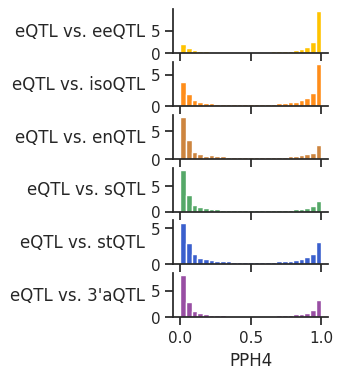

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

sns.set_theme(style="ticks")
fig, axes = plt.subplots(6, 1, figsize=(2, 4), sharex=True)

pairs = ['eQTL vs. eeQTL', 'eQTL vs. isoQTL', "eQTL vs. enQTL", 'eQTL vs. sQTL', 'eQTL vs. stQTL', "eQTL vs. 3'aQTL"]

for i, (ax, pair) in enumerate(zip(axes, pairs)):
    data_subset = df_pp4t[df_pp4t['Pairs'] == pair]['PP.H4.abf']
    ax.hist(data_subset, bins=25, density=True,  
            color=color_dict[pair], range=(0, 1))
    ax.set_ylabel(pair, rotation=0, ha='right', va='center')
    ax.set_ylim(0, None)
    
axes[-1].set_xlabel('PPH4')
sns.despine()
#plt.tight_layout()
plt.savefig('pdf/molQTL_pairs_ppH4_ridge.pdf', dpi='figure', format='pdf', bbox_inches='tight')

# Fig. 3b

In [9]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
df_pp4t = pd.read_csv(f'{path}/coloc_qtl.stat.sig.txt', sep="\t")
df_pp4t['lead_distance'] = (df_pp4t['snp1'].str.split('_').str[1].astype(int) - df_pp4t['snp2'].str.split('_').str[1].astype(int)).abs()
df_pp4t

,qtl,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,phenotype1,phenotype2,chrom,...,is_eGene1,is_eGene2,Shared,pairs,r2,Pairs,Tissue,Sample size,PEER,lead_distance
0,3aQTL,4167,3.588298e-31,8.090776e-05,9.509926e-29,0.020463,0.979456,COPS9,XM_027978770.2|COPS9|chr1|+,chr1,...,True,True,Unique,eQTL_3aQTL,0.289674,eQTL vs. 3'aQTL,Abomasum,228,30,2172
1,3aQTL,3099,3.378199e-07,4.525931e-07,4.156979e-01,0.556902,0.027399,NDUFA10,XM_004001759.4|NDUFA10|chr1|+,chr1,...,True,True,Unique,eQTL_3aQTL,0.008618,eQTL vs. 3'aQTL,Abomasum,228,30,38454
2,3aQTL,2577,1.207184e-12,2.002849e-01,4.751139e-12,0.788254,0.011461,C1H1orf109,XM_042245762.1|C1H1orf109|chr1|-,chr1,...,True,True,Unique,eQTL_3aQTL,0.249645,eQTL vs. 3'aQTL,Abomasum,228,30,27762
3,3aQTL,2577,3.381487e-12,5.610251e-01,2.432736e-12,0.403582,0.035393,C1H1orf109,XM_012099679.4|C1H1orf109|chr1|-,chr1,...,True,True,Unique,eQTL_3aQTL,0.249645,eQTL vs. 3'aQTL,Abomasum,228,30,27762
4,3aQTL,3603,1.002800e-01,5.744902e-02,4.178357e-01,0.239187,0.185248,UTP11,XM_012100981.4|UTP11|chr1|+,chr1,...,True,True,Unique,eQTL_3aQTL,0.076912,eQTL vs. 3'aQTL,Abomasum,228,30,1551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421417,stQTL,3737,3.727566e-01,1.789679e-01,2.619506e-01,0.125707,0.060618,BAG4,BAG4,chr26,...,True,True,Unique,eQTL_stQTL,0.504351,eQTL vs. stQTL,Uterus,178,30,46981
421418,stQTL,3611,1.616101e-01,9.672197e-02,4.356177e-01,0.260667,0.045383,GOLGA7,GOLGA7,chr26,...,True,True,Unique,eQTL_stQTL,0.011286,eQTL vs. stQTL,Uterus,178,30,170078
421419,stQTL,5853,8.359989e-05,1.265090e-04,3.859646e-01,0.584038,0.029787,HGSNAT,HGSNAT,chr26,...,True,True,Unique,eQTL_stQTL,0.202838,eQTL vs. stQTL,Uterus,178,30,10216
421420,stQTL,5737,4.583021e-04,1.047845e-03,1.045882e-01,0.238471,0.655435,CSGALNACT1,CSGALNACT1,chr26,...,True,True,Unique,eQTL_stQTL,0.061363,eQTL vs. stQTL,Uterus,178,30,374537


## fnctions

In [10]:
def load_ld(plink_prefix, ld_prefix, variant_id):
    ## input bim file
    bim_file = f'{plink_prefix}.bim'
    bim_df = pd.read_csv(bim_file, delim_whitespace=True, header=None,
                         names=['CHR', 'variant_id', 'CM', 'BP', 'ALT', 'REF'])
    
    if variant_id in bim_df['variant_id'].values:
        # compute LD
        if not os.path.isfile(f'{ld_prefix}.ld.gz'):
            cmd=f'''/storage/public/home/2020060185/bin/plink \\
                --bfile {plink_prefix} --ld-snp {variant_id} \\
                --sheep --keep-allele-order --r2 gz yes-really \\
                --ld-window-kb 999999 --ld-window 999999 --ld-window-r2 0 \\
                --out {ld_prefix}'''
            os.system(cmd)
            os.remove(f'{ld_prefix}.nosex')
            os.remove(f'{ld_prefix}.log')
        ld_df = pd.read_csv(f'{ld_prefix}.ld.gz', delim_whitespace=True)
        ld_df = ld_df[['SNP_B', 'R2']]
        ld_df.columns = ['variant_id', 'R2']
        ## merge data
        ld_df = pd.merge(bim_df, ld_df, on='variant_id')
        return ld_df
    else:
        warnings.warn(f"{variant_id} is not exist in bim file!")
        return pd.DataFrame()

In [11]:
def multiqtl_locusplot(locuszoom_df, qtl_list=None, variant_id=None, variantid2rsid=None, orientation="vertical", width=3.1, height=2.5, caxw=None, caxh=None):
    tissue = locuszoom_df.dropna()['tissue'].values[0]
    gene = locuszoom_df.dropna()['gene_id'].values[0]
    chrom = locuszoom_df['variant_id'].values[0].split('_')[0].replace('chr', '')
    
    sns.set_theme(style="ticks")
    if not qtl_list:
        qtl_list = locuszoom_df['QTL'].unique()
    if orientation=='vertical':
        fig, axes = plt.subplots(nrows=len(qtl_list), ncols=1, figsize=(width, height*len(qtl_list)), sharex=True, sharey=False)
        if caxw and caxh:
            cax = fig.add_axes([1, 0.5, caxw, caxh])
            
        else:
            cax = fig.add_axes([1, 0.5, 0.1*height/width, 0.03*height])
        axes[0].set_title(f'{gene} in {tissue}')
        axes[-1].set_xlabel(f"Position on chr{chrom} (Mb)")
    elif orientation=='horizontal':
        fig, axes = plt.subplots(ncols=len(qtl_list), nrows=1, figsize=(width*len(qtl_list), height), sharex=True, sharey=True)
        if caxw and caxh:
            cax = fig.add_axes([1, 0.5, caxw, caxh])
        else:
            cax = fig.add_axes([0.91, 0.2, 0.0125*height/width, 0.15*height])
        axes[round(len(qtl_list)/2)-1].set_title(f'{gene} in {tissue}')
        axes[0].set_ylabel(r"-log$_{10}P$")
        axes[round(len(qtl_list)/2)-1].set_xlabel(f"Position on chr{chrom} (Mb)")
        ymax = locuszoom_df['-log10(p-value)'].max()
    
    lz_colors = ["#282973", "#8CCCF0", "#69BD45", "#F9A41A", "#ED1F24"]
    cmap = mpl.colors.ListedColormap(lz_colors)
    bounds = np.arange(0,1.2,0.2)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    ## color bar
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm,
                                   boundaries=bounds, ticks=bounds,
                                   spacing='proportional', orientation='vertical')
    cax.set_title(r'$r^{2}$')
    cax.set_ylim([0,1])
    cax.tick_params(labelsize=10)
    
    i = 0
    for qtl in qtl_list:
        plot_df = locuszoom_df[locuszoom_df['QTL']==qtl]
        if plot_df.empty:
            warnings.warn(f"No valid pval_nominal values found for {qtl}.")
            continue
        pval_nominal_threshold = plot_df['pval_nominal_threshold'][0]
        r2 = plot_df['r2'].max()
        pph4 = plot_df['PP.H4.abf'].max()
        ax = axes[i]
        i += 1
        
        ## scatter plot
        ax.scatter(plot_df['BP']/1e6, plot_df['-log10(p-value)'],
                   c=plot_df['R2'], cmap=cmap, norm=norm, s=10, edgecolor=None)

        ## plot the variant id to highlight
        top_snp = plot_df.loc[plot_df['pval_nominal'].idxmin()]['variant_id']
        top_snp_bp = plot_df[plot_df['variant_id'] == top_snp]['BP'].values[0]
        top_snp_p = plot_df[plot_df['variant_id'] == top_snp]['-log10(p-value)'].values[0]
        if not variant_id:
            # use top SNP instead
            ax.scatter(top_snp_bp/1e6, top_snp_p, color='purple', marker='D', s=50, edgecolor='black')
            if variantid2rsid[top_snp]:
                ax.text(top_snp_bp/1e6*1.001, top_snp_p*1.001, variantid2rsid[top_snp], fontsize=10, ha="center", va="bottom")
            else:
                ax.text(top_snp_bp/1e6*1.001, top_snp_p*1.001, top_snp, fontsize=10, ha="center", va="bottom")
        else:
            variant_id_bp = plot_df[plot_df['variant_id'] == variant_id]['BP'].values[0]
            variant_id_p = plot_df[plot_df['variant_id'] == variant_id]['-log10(p-value)'].values[0]
            ax.scatter(variant_id_bp/1e6, variant_id_p, color='purple', marker='D', s=50, edgecolor='black')
            if variantid2rsid[variant_id]:
                ax.text(variant_id_bp/1e6*1.001, variant_id_p*1.001, variantid2rsid[variant_id], fontsize=10, ha="center", va="bottom")
            else:
                ax.text(variant_id_bp/1e6*1.001, variant_id_p*1.001, variant_id, fontsize=10, ha="center", va="bottom")
        
        ## pvalue threshold
        ax.axhline(y=-np.log10(pval_nominal_threshold), color='red', linestyle='--')
    
        ## annotations
        if qtl=="eQTL":
            annot = f"{qtl}"
        elif qtl=="3aQTL":
            annot = f"3'aQTL\nLD ($r^2$) = {r2:.2f}\n" + r"PP$_{H4}$ = " + f"{pph4:.2f}"
        else:
            annot = f"{qtl}\nLD ($r^2$) = {r2:.2f}\n" + r"PP$_{H4}$ = " + f"{pph4:.2f}"
        xmin = ax.get_xlim()[0]
        if orientation=='vertical':
            ymax = ax.get_ylim()[1]
            ax.set_ylabel(r"-log$_{10}P$")
        ax.text(xmin*1.0001, ymax, annot, fontsize=10, ha="left", va="top")


    fig.subplots_adjust(hspace=0.1)
    sns.despine()
    return fig

In [12]:
#get the number of colocalized significant xQTLs per eGene
#df_count1 = df_pp4t.loc[(df_pp4t['PP.H4.abf']<0.1)&(df_pp4t['r2']<0.1)&(df_pp4t['lead_distance']>500000), ['qtl','tissue','phenotype1','snp1']].drop_duplicates().groupby(['tissue','phenotype1','snp1'])['qtl'].count().reset_index()
#df_count1 = pd.merge(df_count1, dftis, left_on='tissue', right_on="Tissue")
#df_count1.to_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/noncoloc_eqtl.txt', sep="\t", index=False)
df_count1 = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/noncoloc_eqtl.txt', sep="\t")
df_count1

,tissue,phenotype1,snp1,qtl,Tissue,Sample size,PEER
0,Abomasum,ACTR2,3_43080784,1,Abomasum,228,30
1,Abomasum,ANAPC5,17_53817571,1,Abomasum,228,30
2,Abomasum,ARFGEF2,13_76186052,1,Abomasum,228,30
3,Abomasum,ARHGAP12,13_33689008,1,Abomasum,228,30
4,Abomasum,ARMH1,1_19411136,1,Abomasum,228,30
...,...,...,...,...,...,...,...
3230,Uterus,ZNF331,14_61342094,1,Uterus,178,30
3231,Uterus,ZNF575,14_51456918,1,Uterus,178,30
3232,Uterus,ZNF793,14_46594752,1,Uterus,178,30
3233,Uterus,ZNF821,14_38754889,1,Uterus,178,30


In [13]:
examples1 = df_count1.loc[df_count1['qtl']>=1, ['tissue', 'phenotype1', 'snp1']].drop_duplicates()
examples1

,tissue,phenotype1,snp1
0,Abomasum,ACTR2,3_43080784
1,Abomasum,ANAPC5,17_53817571
2,Abomasum,ARFGEF2,13_76186052
3,Abomasum,ARHGAP12,13_33689008
4,Abomasum,ARMH1,1_19411136
...,...,...,...
3230,Uterus,ZNF331,14_61342094
3231,Uterus,ZNF575,14_51456918
3232,Uterus,ZNF793,14_46594752
3233,Uterus,ZNF821,14_38754889


In [14]:
# for specific samples
pathe = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
path3a = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/06.3aQTL"
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
#for row in examples1.itertuples():
#    print(f"{row.tissue}, {row.phenotype1}, {row.snp1}")

## ARIH2 in Longissimus muscle (isoQTL)

In [15]:
tissue, phenotype_id, variant_id = examples1[(examples1['tissue']=='Longissimus_muscle')&(examples1['phenotype1']=='ARIH2')].values[0]
pp4r2_df = df_pp4t.loc[(df_pp4t['tissue']==tissue)&(df_pp4t['phenotype1']==phenotype_id), ['qtl','tissue','phenotype1','phenotype2','snp1','snp2','PP.H4.abf','r2']]
chrom = 'chr' + variant_id.split('_')[0]
qtl_list = np.insert(pp4r2_df['qtl'].unique(), 0, 'eQTL')
print(tissue, phenotype_id, variant_id, qtl_list)
pp4r2_df

Longissimus_muscle ARIH2 19_50492636 ['eQTL' 'isoQTL']


,qtl,tissue,phenotype1,phenotype2,snp1,snp2,PP.H4.abf,r2
232818,isoQTL,Longissimus_muscle,ARIH2,ARIH2:XM_027957665.2,19_50492636,19_51048469,0.028628,0.06648
232819,isoQTL,Longissimus_muscle,ARIH2,ARIH2:XM_042236243.1,19_50492636,19_51048469,0.029672,0.06648


In [62]:
locuszoom_df1 = pd.DataFrame()
qtlplot_list = list(qtl_list)
for qtl in qtl_list:
    os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
    print(qtl)
    # get LD information of the top SNP of each type of molQTL
    perm_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.permutation.txt', sep='\t', usecols=['phenotype_id0','phenotype_id','variant_id','pval_nominal_threshold','is_eGene'])
    perm_df =  perm_df.rename(columns={'phenotype_id0':'phenotype_id','phenotype_id':'gene_id', 'variant_id':'top_snp'})
    if phenotype_id in perm_df['gene_id'].values:
        top_snp = perm_df.loc[perm_df['gene_id']==phenotype_id, 'top_snp'].values[0]
    else:
        warnings.warn(f"{phenotype_id} is not exist in {qtl} permutation file!")
        qtlplot_list.remove(qtl)
        continue
    
    if qtl=='3aQTL':
        plink_prefix = f'{path3a}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}.3a'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    else:
        plink_prefix = f'{pathe}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    if df_ld.empty:
        warnings.warn(f"{top_snp} does not exist in {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    
    # get QTL information
    gwas_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.nominal/{tissue}.cis_qtl_pairs.{chrom}.txt.gz', sep='\t')
    if os.path.exists(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt'):
        phenogroup = pd.read_csv(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt', sep="\t")
        gwas_df = pd.merge(gwas_df, phenogroup, on='phenotype_id')
    else:
        gwas_df['gene_id'] = gwas_df['phenotype_id']
    gwas_df = gwas_df[gwas_df['gene_id']==phenotype_id]
    gwas_df = gwas_df.dropna(subset=['pval_nominal'])
    if gwas_df.empty:
        warnings.warn(f"No valid pval_nominal values found for {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    gwas_df = pd.merge(gwas_df, perm_df, on=['phenotype_id','gene_id'])
    ## merge data
    locuszoom_df_ = pd.merge(gwas_df, df_ld, on='variant_id', how='left')
    locuszoom_df_['QTL'] = qtl
    locuszoom_df_ = pd.merge(locuszoom_df_, pp4r2_df, left_on=['QTL','gene_id','phenotype_id'], right_on=['qtl','phenotype1','phenotype2'], how='left')
    locuszoom_df1 = pd.concat([locuszoom_df1, locuszoom_df_])

locuszoom_df1['-log10(p-value)'] = -np.log10(locuszoom_df1['pval_nominal'])
locuszoom_df1 = locuszoom_df1.sort_values(by='R2', ascending=True)

eQTL
isoQTL


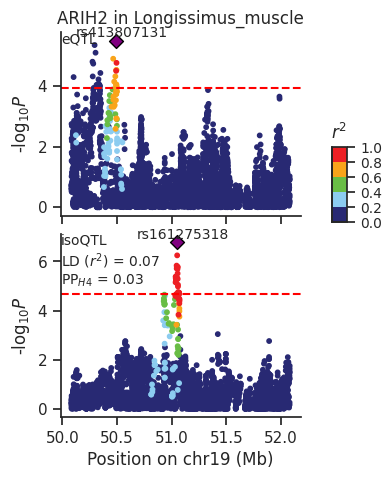

In [66]:
variantid2rsid = {'19_50492636':'rs413807131', '19_51048469':'rs161275318'}
multiqtl_locusplot(locuszoom_df1, qtl_list=qtlplot_list, variantid2rsid=variantid2rsid, caxw=0.05, caxh=0.15)
#plt.savefig("./pdf/{tissue}_{phenotype_id}_isoQTL.pdf", bbox_inches='tight')

## C21H11orf86 in Small intestine (enQTL)

In [70]:
tissue, phenotype_id, variant_id = examples1[(examples1['tissue']=='Small_intestine')&(examples1['phenotype1']=='C21H11orf86')].values[0]
pp4r2_df = df_pp4t.loc[(df_pp4t['tissue']==tissue)&(df_pp4t['phenotype1']==phenotype_id), ['qtl','tissue','phenotype1','phenotype2','snp1','snp2','PP.H4.abf','r2']]
chrom = 'chr' + variant_id.split('_')[0]
qtl_list = np.insert(pp4r2_df['qtl'].unique(), 0, 'eQTL')
print(tissue, phenotype_id, variant_id, qtl_list)
pp4r2_df

Small_intestine C21H11orf86 21_40598078 ['eQTL' 'enQTL']


,qtl,tissue,phenotype1,phenotype2,snp1,snp2,PP.H4.abf,r2
196999,enQTL,Small_intestine,C21H11orf86,C21H11orf86:enhancer_chr21:41390800:41391200,21_40598078,21_41389752,0.03563,0.00466


In [71]:
locuszoom_df1 = pd.DataFrame()
qtlplot_list = list(qtl_list)
for qtl in qtl_list:
    os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
    print(qtl)
    # get LD information of the top SNP of each type of molQTL
    perm_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.permutation.txt', sep='\t', usecols=['phenotype_id0','phenotype_id','variant_id','pval_nominal_threshold','is_eGene'])
    perm_df =  perm_df.rename(columns={'phenotype_id0':'phenotype_id','phenotype_id':'gene_id', 'variant_id':'top_snp'})
    if phenotype_id in perm_df['gene_id'].values:
        top_snp = perm_df.loc[perm_df['gene_id']==phenotype_id, 'top_snp'].values[0]
    else:
        warnings.warn(f"{phenotype_id} is not exist in {qtl} permutation file!")
        qtlplot_list.remove(qtl)
        continue
    
    if qtl=='3aQTL':
        plink_prefix = f'{path3a}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}.3a'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    else:
        plink_prefix = f'{pathe}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    if df_ld.empty:
        warnings.warn(f"{top_snp} does not exist in {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    
    # get QTL information
    gwas_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.nominal/{tissue}.cis_qtl_pairs.{chrom}.txt.gz', sep='\t')
    if os.path.exists(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt'):
        phenogroup = pd.read_csv(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt', sep="\t")
        gwas_df = pd.merge(gwas_df, phenogroup, on='phenotype_id')
    else:
        gwas_df['gene_id'] = gwas_df['phenotype_id']
    gwas_df = gwas_df[gwas_df['gene_id']==phenotype_id]
    gwas_df = gwas_df.dropna(subset=['pval_nominal'])
    if gwas_df.empty:
        warnings.warn(f"No valid pval_nominal values found for {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    gwas_df = pd.merge(gwas_df, perm_df, on=['phenotype_id','gene_id'])
    ## merge data
    locuszoom_df_ = pd.merge(gwas_df, df_ld, on='variant_id', how='left')
    locuszoom_df_['QTL'] = qtl
    locuszoom_df_ = pd.merge(locuszoom_df_, pp4r2_df, left_on=['QTL','gene_id','phenotype_id'], right_on=['qtl','phenotype1','phenotype2'], how='left')
    locuszoom_df1 = pd.concat([locuszoom_df1, locuszoom_df_])

locuszoom_df1['-log10(p-value)'] = -np.log10(locuszoom_df1['pval_nominal'])
locuszoom_df1 = locuszoom_df1.sort_values(by='R2', ascending=True)

eQTL
enQTL


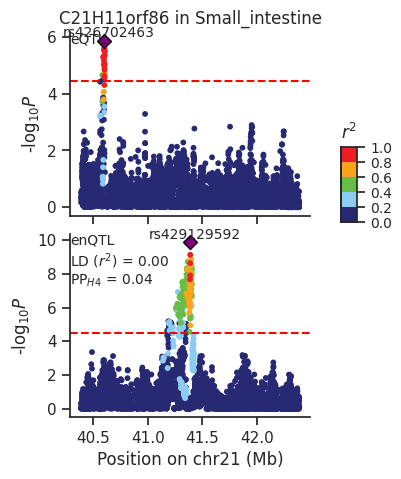

In [72]:
variantid2rsid = {'21_40598078':'rs426702463', '21_41389752':'rs429129592'}
multiqtl_locusplot(locuszoom_df1, qtl_list=qtlplot_list, variantid2rsid=variantid2rsid, caxw=0.05, caxh=0.15)
#plt.savefig("./pdf/{tissue}_{phenotype_id}_isoQTL.pdf", bbox_inches='tight')

## STXBP1 in Brain (sQTL)

In [73]:
tissue, phenotype_id, variant_id = examples1[(examples1['tissue']=='Brain')&(examples1['phenotype1']=='STXBP1')].values[0]
pp4r2_df = df_pp4t.loc[(df_pp4t['tissue']==tissue)&(df_pp4t['phenotype1']==phenotype_id), ['qtl','tissue','phenotype1','phenotype2','snp1','snp2','PP.H4.abf','r2']]
chrom = 'chr' + variant_id.split('_')[0]
qtl_list = np.insert(pp4r2_df['qtl'].unique(), 0, 'eQTL')
print(tissue, phenotype_id, variant_id, qtl_list)
pp4r2_df

Brain STXBP1 3_8528813 ['eQTL' 'sQTL']


,qtl,tissue,phenotype1,phenotype2,snp1,snp2,PP.H4.abf,r2
33918,sQTL,Brain,STXBP1,chr3:8511128:8518539:clu_97278_-:STXBP1,3_8528813,3_9085758,0.035467,0.002405


In [74]:
locuszoom_df1 = pd.DataFrame()
qtlplot_list = list(qtl_list)
for qtl in qtl_list:
    os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
    print(qtl)
    # get LD information of the top SNP of each type of molQTL
    perm_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.permutation.txt', sep='\t', usecols=['phenotype_id0','phenotype_id','variant_id','pval_nominal_threshold','is_eGene'])
    perm_df =  perm_df.rename(columns={'phenotype_id0':'phenotype_id','phenotype_id':'gene_id', 'variant_id':'top_snp'})
    if phenotype_id in perm_df['gene_id'].values:
        top_snp = perm_df.loc[perm_df['gene_id']==phenotype_id, 'top_snp'].values[0]
    else:
        warnings.warn(f"{phenotype_id} is not exist in {qtl} permutation file!")
        qtlplot_list.remove(qtl)
        continue
    
    if qtl=='3aQTL':
        plink_prefix = f'{path3a}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}.3a'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    else:
        plink_prefix = f'{pathe}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    if df_ld.empty:
        warnings.warn(f"{top_snp} does not exist in {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    
    # get QTL information
    gwas_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.nominal/{tissue}.cis_qtl_pairs.{chrom}.txt.gz', sep='\t')
    if os.path.exists(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt'):
        phenogroup = pd.read_csv(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt', sep="\t")
        gwas_df = pd.merge(gwas_df, phenogroup, on='phenotype_id')
    else:
        gwas_df['gene_id'] = gwas_df['phenotype_id']
    gwas_df = gwas_df[gwas_df['gene_id']==phenotype_id]
    gwas_df = gwas_df.dropna(subset=['pval_nominal'])
    if gwas_df.empty:
        warnings.warn(f"No valid pval_nominal values found for {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    gwas_df = pd.merge(gwas_df, perm_df, on=['phenotype_id','gene_id'])
    ## merge data
    locuszoom_df_ = pd.merge(gwas_df, df_ld, on='variant_id', how='left')
    locuszoom_df_['QTL'] = qtl
    locuszoom_df_ = pd.merge(locuszoom_df_, pp4r2_df, left_on=['QTL','gene_id','phenotype_id'], right_on=['qtl','phenotype1','phenotype2'], how='left')
    locuszoom_df1 = pd.concat([locuszoom_df1, locuszoom_df_])

locuszoom_df1['-log10(p-value)'] = -np.log10(locuszoom_df1['pval_nominal'])
locuszoom_df1 = locuszoom_df1.sort_values(by='R2', ascending=True)

eQTL
sQTL


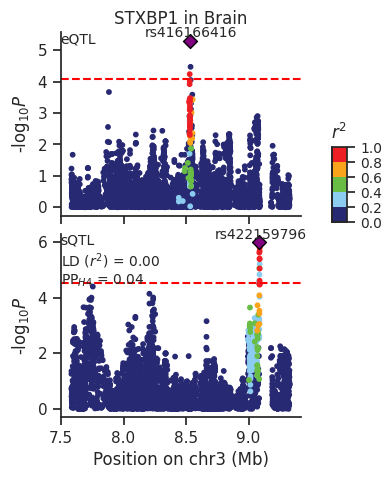

In [75]:
variantid2rsid = {'3_8528813':'rs416166416', '3_9085758':'rs422159796'}
multiqtl_locusplot(locuszoom_df1, qtl_list=qtlplot_list, variantid2rsid=variantid2rsid, caxw=0.05, caxh=0.15)
#plt.savefig("./pdf/{tissue}_{phenotype_id}_isoQTL.pdf", bbox_inches='tight')

## SAMD14 in Pituitary (3a'QTL)

In [76]:
tissue, phenotype_id, variant_id = examples1[(examples1['tissue']=='Pituitary')&(examples1['phenotype1']=='SAMD14')].values[0]
pp4r2_df = df_pp4t.loc[(df_pp4t['tissue']==tissue)&(df_pp4t['phenotype1']==phenotype_id), ['qtl','tissue','phenotype1','phenotype2','snp1','snp2','PP.H4.abf','r2']]
chrom = 'chr' + variant_id.split('_')[0]
qtl_list = np.insert(pp4r2_df['qtl'].unique(), 0, 'eQTL')
print(tissue, phenotype_id, variant_id, qtl_list)
pp4r2_df

Pituitary SAMD14 11_36274820 ['eQTL' '3aQTL' 'isoQTL']


,qtl,tissue,phenotype1,phenotype2,snp1,snp2,PP.H4.abf,r2
171794,3aQTL,Pituitary,SAMD14,XM_042255834.1|SAMD14|chr11|+,11_36274820,11_35346554,0.019305,0.002395
176404,isoQTL,Pituitary,SAMD14,SAMD14:XM_015098718.3,11_36274820,11_36260134,0.996466,0.570554


In [77]:
locuszoom_df1 = pd.DataFrame()
qtlplot_list = list(qtl_list)
for qtl in qtl_list:
    os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
    print(qtl)
    # get LD information of the top SNP of each type of molQTL
    perm_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.permutation.txt', sep='\t', usecols=['phenotype_id0','phenotype_id','variant_id','pval_nominal_threshold','is_eGene'])
    perm_df =  perm_df.rename(columns={'phenotype_id0':'phenotype_id','phenotype_id':'gene_id', 'variant_id':'top_snp'})
    if phenotype_id in perm_df['gene_id'].values:
        top_snp = perm_df.loc[perm_df['gene_id']==phenotype_id, 'top_snp'].values[0]
    else:
        warnings.warn(f"{phenotype_id} is not exist in {qtl} permutation file!")
        qtlplot_list.remove(qtl)
        continue
    
    if qtl=='3aQTL':
        plink_prefix = f'{path3a}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}.3a'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    else:
        plink_prefix = f'{pathe}/{tissue}/genotypes/{tissue}'
        ld_prefix = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{top_snp}'
        df_ld = load_ld(plink_prefix, ld_prefix, variant_id=top_snp)
    if df_ld.empty:
        warnings.warn(f"{top_snp} does not exist in {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    
    # get QTL information
    gwas_df = pd.read_csv(f'{path}/{tissue}/qtls/{qtl}.nominal/{tissue}.cis_qtl_pairs.{chrom}.txt.gz', sep='\t')
    if os.path.exists(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt'):
        phenogroup = pd.read_csv(f'{path}/{tissue}/phenotypes/{qtl}.phenotype_groups.txt', sep="\t")
        gwas_df = pd.merge(gwas_df, phenogroup, on='phenotype_id')
    else:
        gwas_df['gene_id'] = gwas_df['phenotype_id']
    gwas_df = gwas_df[gwas_df['gene_id']==phenotype_id]
    gwas_df = gwas_df.dropna(subset=['pval_nominal'])
    if gwas_df.empty:
        warnings.warn(f"No valid pval_nominal values found for {tissue} {phenotype_id} {qtl}.")
        qtlplot_list.remove(qtl)
        continue
    gwas_df = pd.merge(gwas_df, perm_df, on=['phenotype_id','gene_id'])
    ## merge data
    locuszoom_df_ = pd.merge(gwas_df, df_ld, on='variant_id', how='left')
    locuszoom_df_['QTL'] = qtl
    locuszoom_df_ = pd.merge(locuszoom_df_, pp4r2_df, left_on=['QTL','gene_id','phenotype_id'], right_on=['qtl','phenotype1','phenotype2'], how='left')
    locuszoom_df1 = pd.concat([locuszoom_df1, locuszoom_df_])

locuszoom_df1['-log10(p-value)'] = -np.log10(locuszoom_df1['pval_nominal'])
locuszoom_df1 = locuszoom_df1.sort_values(by='R2', ascending=True)

eQTL
PLINK v1.90b7 64-bit (16 Jan 2023)             www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Pituitary/local/locuszoom/SAMD14/SAMD14.11_36274820.log.
Options in effect:
  --bfile /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split/Pituitary/genotypes/Pituitary
  --keep-allele-order
  --ld-snp 11_36274820
  --ld-window 999999
  --ld-window-kb 999999
  --ld-window-r2 0
  --out /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/Pituitary/local/locuszoom/SAMD14/SAMD14.11_36274820
  --r2 gz yes-really
  --sheep

515121 MB RAM detected; reserving 257560 MB for main workspace.
3263516 variants loaded from .bim file.
284 sheep (0 males, 0 females, 284 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepG

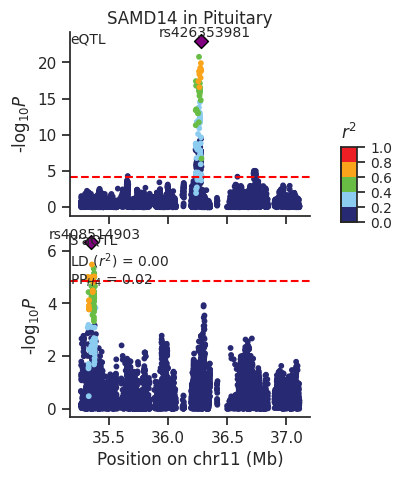

In [79]:
variantid2rsid = {'11_36274820':'rs426353981', '11_35346554':'rs408514903'}
multiqtl_locusplot(locuszoom_df1, qtl_list=['eQTL', '3aQTL'], variantid2rsid=variantid2rsid, caxw=0.05, caxh=0.15)
#plt.savefig("./pdf/{tissue}_{phenotype_id}_isoQTL.pdf", bbox_inches='tight')

# Fig. 3c-f

In [5]:
#get the number of colocalized (PPH4>0.5) significant xQTLs per eGene
#df_count = df_pp4t.loc[df_pp4t['PP.H4.abf']>0.5, ['qtl','tissue','gene','snp1']].drop_duplicates().groupby(['tissue','gene','snp1'])['qtl'].count().reset_index()
#df_eqtl = df_shared.loc[df_shared['is_eGene1']==True, ['tissue','gene','snp1']].drop_duplicates()
#df_count = pd.merge(df_eqtl, df_count, how='left', on=['tissue','gene','snp1']).fillna(0)
#df_count['num'] = df_count['qtl']
#df_count.loc[df_count['num']>=3, 'num'] = 3
#df_count = pd.merge(df_count, dftis, left_on='tissue', right_on="Tissue")
#df_count.to_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/pleiotropic_eqtl.txt', sep="\t", index=False)
df_count = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc/pleiotropic_eqtl.txt', sep="\t")
df_count

,tissue,gene,snp1,qtl,num,Tissue,Sample size,PEER
0,Abomasum,LOC114113923,1_75039,1.0,1.0,Abomasum,228,30
1,Abomasum,D2HGDH,1_182482,1.0,1.0,Abomasum,228,30
2,Abomasum,BOK,1_342215,1.0,1.0,Abomasum,228,30
3,Abomasum,STK25,1_368419,0.0,0.0,Abomasum,228,30
4,Abomasum,FARP2,1_364737,0.0,0.0,Abomasum,228,30
...,...,...,...,...,...,...,...,...
167385,Uterus,LOC105605187,26_24204407,1.0,1.0,Uterus,178,30
167386,Uterus,LOC105609538,6_97899735,0.0,0.0,Uterus,178,30
167387,Uterus,SLIT1,22_18303805,0.0,0.0,Uterus,178,30
167388,Uterus,LOC114110662,24_2872925,0.0,0.0,Uterus,178,30


In [33]:
df_count['num'].value_counts()/df_count['num'].value_counts().sum()

num
0.0    0.410293
1.0    0.388494
2.0    0.149238
3.0    0.051974
Name: count, dtype: float64

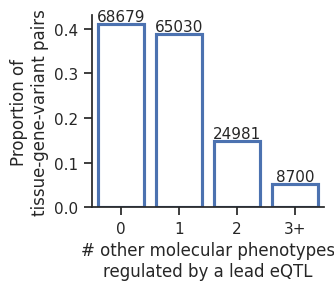

In [35]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.barplot(df_count['num'].value_counts()/df_count['num'].value_counts().sum(), fill=False)
ax.bar_label(ax.containers[0], labels=df_count['num'].value_counts().values, fontsize=11)
plt.xlabel('# other molecular phenotypes\nregulated by a lead eQTL')
plt.xticks([0,1,2,3], [0,1,2,'3+'])
plt.ylabel('Proportion of\ntissue-gene-variant pairs')
plt.savefig('pdf/bar_molpheno_lead_eSNP.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

In [8]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
afc = pd.read_csv(f"{path}/log2aFC0.txt", sep="\t", 
                  usecols=['Tissue','variant_id','start_distance','phenotype_id','af','slope','slope_se','log2_aFC','is_eGene'])
afc['|log2aFC|'] = afc['log2_aFC'].abs()
afc = afc[afc['|log2aFC|']<6.64] # remove outliers
afc['MAF'] = afc['af'].apply(lambda x: 1 - x if x > 0.5 else x)
afc['|slope|'] = afc['slope'].abs()
afc['Z'] = afc['slope'] / afc['slope_se']
afc['|Z|'] = afc['Z'].abs()
afc['start_distance (kb)'] = afc['start_distance']/1000
afc['Distance to TSS (kb)'] = abs(afc['start_distance (kb)'])
#afc['Distance to TSS (Mb)'] = abs(afc['start_distance'])/1000000
afct = afc[afc['is_eGene']==True]
df_afct = pd.merge(df_count, afct, left_on=["Tissue", "gene","snp1"], right_on=["Tissue", "phenotype_id","variant_id"])
df_afct

,tissue,gene,snp1,qtl,num,Tissue,Sample size,PEER,phenotype_id,variant_id,...,slope_se,is_eGene,log2_aFC,|log2aFC|,MAF,|slope|,Z,|Z|,start_distance (kb),Distance to TSS (kb)
0,Abomasum,LOC114113923,1_75039,1.0,1.0,Abomasum,228,30,LOC114113923,1_75039,...,0.093533,True,-0.940323,0.940323,0.116228,0.512098,-5.475052,5.475052,-2.973,2.973
1,Abomasum,D2HGDH,1_182482,1.0,1.0,Abomasum,228,30,D2HGDH,1_182482,...,0.037746,True,-0.260751,0.260751,0.254386,0.175564,-4.651232,4.651232,-54.178,54.178
2,Abomasum,BOK,1_342215,1.0,1.0,Abomasum,228,30,BOK,1_342215,...,0.042216,True,0.371501,0.371501,0.364035,0.244830,5.799446,5.799446,-1.756,1.756
3,Abomasum,STK25,1_368419,0.0,0.0,Abomasum,228,30,STK25,1_368419,...,0.038486,True,-0.017835,0.017835,0.164474,0.221370,-5.751992,5.751992,1.158,1.158
4,Abomasum,FARP2,1_364737,0.0,0.0,Abomasum,228,30,FARP2,1_364737,...,0.059361,True,-0.305274,0.305274,0.263158,0.328981,-5.542077,5.542077,-113.153,113.153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164969,Uterus,LOC101105937,13_52937510,0.0,0.0,Uterus,178,30,LOC101105937,13_52937510,...,0.166483,True,1.402160,1.402160,0.087079,0.757007,4.547053,4.547053,-263.641,263.641
164970,Uterus,LOC105605187,26_24204407,1.0,1.0,Uterus,178,30,LOC105605187,26_24204407,...,0.058676,True,1.861523,1.861523,0.480337,0.709889,12.098353,12.098353,-1.880,1.880
164971,Uterus,LOC105609538,6_97899735,0.0,0.0,Uterus,178,30,LOC105609538,6_97899735,...,0.031932,True,-0.204618,0.204618,0.497191,0.148962,-4.665005,4.665005,96.827,96.827
164972,Uterus,LOC114110662,24_2872925,0.0,0.0,Uterus,178,30,LOC114110662,24_2872925,...,0.142315,True,1.238210,1.238210,0.050562,0.838361,5.890883,5.890883,-16.636,16.636


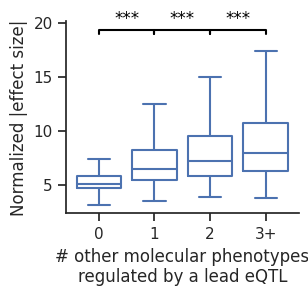

In [37]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.boxplot(data=df_afct, y='|Z|', x='num', fill=False, showfliers=False)
plt.xlabel('# other molecular phenotypes\nregulated by a lead eQTL')
plt.ylabel('Normalized |effect size|')
plt.xticks([0,1,2,3], [0,1,2,'3+'])

#y_max = max(df_afct['|Z|']) * 1.1
y_max = 19
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(df_afct.loc[df_afct['num']==pair[0],'|Z|'],
                                         df_afct.loc[df_afct['num']==pair[1],'|Z|'], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/effect_molphene_eSNP.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

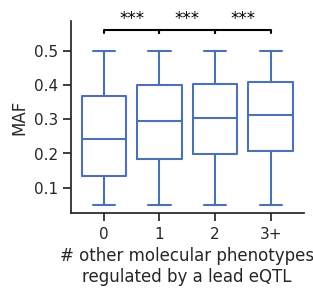

In [38]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.boxplot(data=df_afct, y='MAF', x='num', fill=False)
plt.xlabel('# other molecular phenotypes\nregulated by a lead eQTL')
plt.xticks([0,1,2,3], [0,1,2,'3+'])

y_max = max(df_afct['MAF']) * 1.1
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(df_afct.loc[df_afct['num']==pair[0],'MAF'],
                                         df_afct.loc[df_afct['num']==pair[1],'MAF'], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/MAF_molphene_eSNP.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

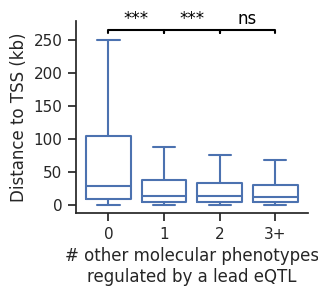

In [40]:
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.boxplot(data=df_afct, y='Distance to TSS (kb)', x='num', fill=False, showfliers=False)
plt.xlabel('# other molecular phenotypes\nregulated by a lead eQTL')
plt.xticks([0,1,2,3], [0,1,2,'3+'])

#y_max = max(df_afct['Distance to TSS (kb)']) * 1.1
y_max = 260
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(df_afct.loc[df_afct['num']==pair[0],'Distance to TSS (kb)'],
                                         df_afct.loc[df_afct['num']==pair[1],'Distance to TSS (kb)'], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/tss_molphene_eSNP.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

# Fig. 3g

In [41]:
label_mapping = {'intergenic_region':'intergenic','upstream_gene':'upstream','downstream_gene':'downstream','5_prime_UTR':"5' UTR",'3_prime_UTR':"3' UTR",
                 '5_prime_UTR_premature_start_codon_gain':"5' UTR premature\nstart codon gain",'non_coding_transcript_exon':'non-coding\ntranscript exon',
                 'splice_region':'splice region','splice_acceptor':'splice acceptor','splice_donor':'splice donor','start_lost':'start lost','stop_lost':'stop lost',
                 'stop_gained':'stop gained','stop_retained':'stop retained','initiator_codon':'initiator codon',
                 "E1":"TssA", "E2":"TssAHet", "E3":"TxFlnk", "E4":"TxFlnkWk", "E5":"TxFlnkHet", "E6":"EnhA", "E7":"EnhAMe", "E8":"EnhAWk",
                 "E9":"EnhAHet", "E10":"EnhPois", "E11":"ATAC_Is", "E12":"TssBiv", "E13":"Repr", "E14":"ReprWk", "E15":"Qui"}

path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
df_enrich = pd.DataFrame()

# odds ratio
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/results/pleiotropic/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/results/pleiotropic/OR_results.csv')
        df_['Tissue'] = tis
        df_enrich = pd.concat([df_enrich, df_])
df_enrich['num'] = df_enrich['QTL'].str.replace('.txt', '', regex=False)
df_enrich['Annotation'] = df_enrich['Annotation'].str.replace('.txt', '', regex=False)
df_enrich['Annotation'] = df_enrich['Annotation'].str.replace('_variant', '', regex=False)
df_enrich = df_enrich.rename(columns={'OR':'Odds ratio'})
df_enrich = df_enrich.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df_enrich['log\u2082(Odds ratio)'] = np.log2(df_enrich['Odds ratio'])
df_enrich = pd.merge(df_enrich, dftis, on='Tissue')
df_ontology = df_enrich[~df_enrich['Annotation'].str.startswith('E')].reset_index()
df_state = df_enrich[df_enrich['Annotation'].str.startswith('E')].reset_index()
df_enrich['Annotation'] = df_enrich['Annotation'].replace(label_mapping)
df_ontology['Annotation'] = df_ontology['Annotation'].replace(label_mapping)
df_state['Annotation'] = df_state['Annotation'].replace(label_mapping)
df_enrich

,QTL,Annotation,Odds ratio,95% CI Low,95% CI High,P-value,num_var,Tissue,num,log₂(Odds ratio),Sample size,PEER
0,1.txt,intergenic,0.958979,-0.111670,2.029628,2.344028e-01,4456,Muscle,1,-0.060429,713,60
1,1.txt,downstream,1.889131,0.817473,2.960788,1.250556e-64,4456,Muscle,1,0.917722,713,60
2,1.txt,start lost,15.683939,11.627488,19.740390,7.686837e-03,4456,Muscle,1,3.971216,713,60
3,1.txt,5' UTR premature\nstart codon gain,2.913364,1.441928,4.384800,2.690644e-06,4456,Muscle,1,1.542686,713,60
4,1.txt,EnhAHet,0.972618,-0.095895,2.041131,4.200612e-01,4456,Muscle,1,-0.040056,713,60
...,...,...,...,...,...,...,...,...,...,...,...,...
5035,0.txt,splice donor,2563.434555,2555.267385,2571.601725,4.480512e-04,8,Oviduct,0,11.323862,40,15
5036,0.txt,intragenic,34.974642,26.845997,43.103286,3.208643e-02,8,Oviduct,0,5.128237,40,15
5037,0.txt,TxFlnkWk,0.834775,-7.293350,8.962900,1.000000e+00,8,Oviduct,0,-0.260540,40,15
5038,0.txt,TxFlnk,1.831388,-3.123309,6.786085,3.554289e-01,8,Oviduct,0,0.872938,40,15


In [14]:
label_mapping = {'intergenic_region':'intergenic','upstream_gene':'upstream','downstream_gene':'downstream','5_prime_UTR':"5' UTR",'3_prime_UTR':"3' UTR",
                 '5_prime_UTR_premature_start_codon_gain':"5' UTR premature\nstart codon gain",'non_coding_transcript_exon':'non-coding\ntranscript exon',
                 'splice_region':'splice region','splice_acceptor':'splice acceptor','splice_donor':'splice donor','start_lost':'start lost','stop_lost':'stop lost',
                 'stop_gained':'stop gained','stop_retained':'stop retained','initiator_codon':'initiator codon',
                 "E1":"TssA", "E2":"TssAHet", "E3":"TxFlnk", "E4":"TxFlnkWk", "E5":"TxFlnkHet", "E6":"EnhA", "E7":"EnhAMe", "E8":"EnhAWk",
                 "E9":"EnhAHet", "E10":"EnhPois", "E11":"ATAC_Is", "E12":"TssBiv", "E13":"Repr", "E14":"ReprWk", "E15":"Qui"}

path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"

# focal SNPs
df1 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/results/pleiotropic/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/results/pleiotropic/OR_results.csv')
        df_['Tissue'] = tis
        df1 = pd.concat([df1, df_])
df1['QTL'] = df1['QTL'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('_variant', '', regex=False)
df1['log2(odds ratio)'] = np.log2(df1['Odds ratio'])
df1 = df1.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df1['Source'] = 'molQTL'

# control SNPs
df2 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/results/pleiotropic/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/results/pleiotropic/OR_control_results.csv')
        df_['Tissue'] = tis
        df2 = pd.concat([df2, df_])
df2['QTL'] = df2['QTL'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('_variant', '', regex=False)
df2['log2(odds ratio)'] = np.log2(df2['Odds ratio'])
df2 = df2.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df2['Source'] = 'Control'

# merge
df_enrich = pd.concat([df1, df2], ignore_index=True)
df_ontology = df_enrich[~df_enrich['Annotation'].str.startswith('E')].reset_index(drop=True)
df_state = df_enrich[df_enrich['Annotation'].str.startswith('E')].reset_index(drop=True)
df_enrich['Annotation'] = df_enrich['Annotation'].replace(label_mapping)
df_ontology['Annotation'] = df_ontology['Annotation'].replace(label_mapping)
df_state['Annotation'] = df_state['Annotation'].replace(label_mapping)
df_enrich

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,QTL,Annotation,Odds ratio,95% CI Low,95% CI High,P-value,num_var,Tissue,log2(odds ratio),Source
0,1,intergenic,0.958979,0.895699,1.026730,2.344028e-01,4456,Muscle,-0.060429,molQTL
1,1,downstream,1.889131,1.762812,2.024501,1.250556e-64,4456,Muscle,0.917722,molQTL
2,1,start lost,15.683939,3.866419,63.621128,7.686837e-03,4456,Muscle,3.971216,molQTL
3,1,5' UTR premature\nstart codon gain,2.913364,1.979947,4.286829,2.690644e-06,4456,Muscle,1.542686,molQTL
4,1,EnhAHet,0.972618,0.910253,1.039254,4.200612e-01,4456,Muscle,-0.040056,molQTL
...,...,...,...,...,...,...,...,...,...,...
10921,0,intragenic,1.386066,1.033542,1.858831,3.426365e-02,8000,Oviduct,0.470996,Control
10922,0,stop gained,1.960849,0.274931,13.985069,4.005675e-01,8000,Oviduct,0.971478,Control
10923,0,TxFlnkWk,1.077182,1.013919,1.144393,1.672622e-02,8000,Oviduct,0.107262,Control
10924,0,TxFlnk,1.012646,0.953176,1.075826,6.868215e-01,8000,Oviduct,0.018130,Control


/tmp/ipykernel_1777/1611479049.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_1777/1611479049.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


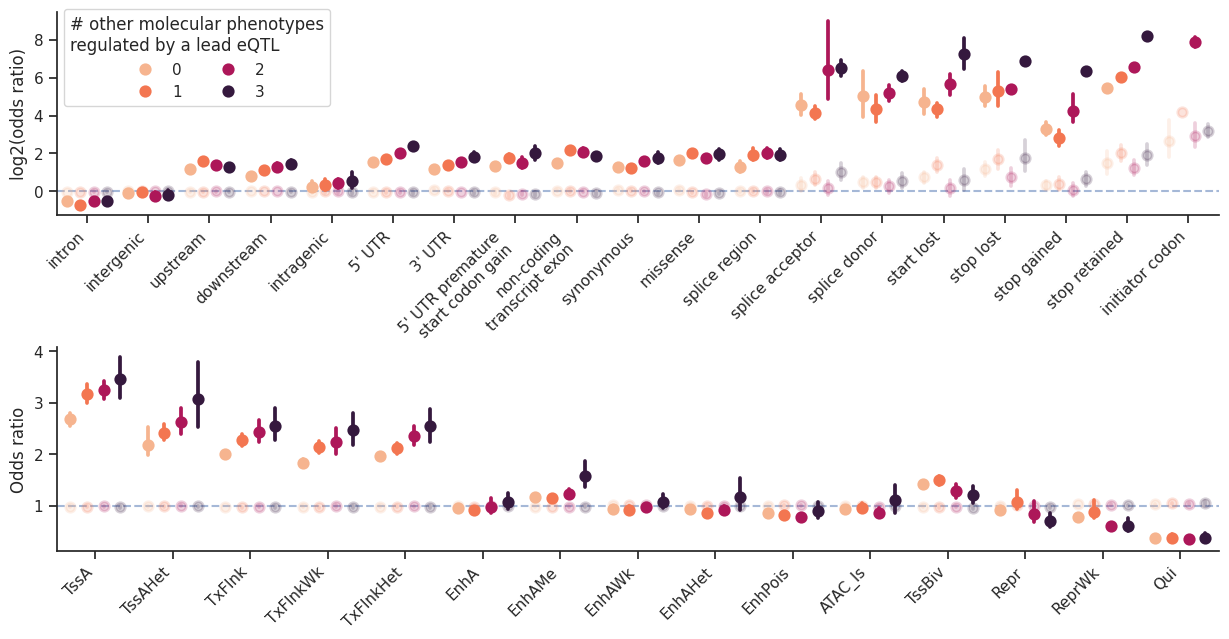

In [17]:
x_order1=['intron', 'intergenic', 'upstream', 'downstream', 'intragenic', "5' UTR","3' UTR", "5' UTR premature\nstart codon gain", 'non-coding\ntranscript exon',
          'synonymous', 'missense', 'splice region', 'splice acceptor', 'splice donor', 'start lost', 'stop lost', 'stop gained', 'stop retained', 'initiator codon']
x_order2=["TssA", "TssAHet", "TxFlnk", "TxFlnkWk", "TxFlnkHet", "EnhA", "EnhAMe", "EnhAWk", "EnhAHet", "EnhPois", "ATAC_Is", "TssBiv", "Repr", "ReprWk", "Qui"]

def plot_enrichment(ax, df, x_order, y_col, baseline, color_dict, title=None, legend=True):
    ax.axhline(baseline, color="b", linestyle="--", alpha=0.5)

    # control SNPs    
    sns.pointplot(data=df[df['Source']=="Control"], x="Annotation", y=y_col, hue="QTL", 
                  hue_order=['0', '1', '2', '3'], legend=False, order=x_order,
                  palette=color_dict, markers="o", dodge=.65, alpha=.2, linestyles="none", ax=ax)
    
    # focal SNPs
    sns.pointplot(data=df[df['Source']=="molQTL"], x="Annotation", y=y_col, hue="QTL", 
                  hue_order=['0', '1', '2', '3'], legend=legend, order=x_order,
                  palette=color_dict, markers="o", dodge=.65, linestyles="none", ax=ax)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_title(title)

    return ax

sns.set_theme(style="ticks")
fig, axes = plt.subplots(2, 1, figsize=(15,7), sharex=False)
# ontology
plot_enrichment(ax=axes[0], df=df_ontology, x_order=x_order1, y_col="log2(odds ratio)", baseline=0, color_dict=color_dict1, title="")
# chromatin state
plot_enrichment(ax=axes[1], df=df_state, x_order=x_order2, y_col="Odds ratio", baseline=1, color_dict=color_dict1, title="", legend=False)
sns.move_legend(axes[0], "upper left", ncol=2, title="# other molecular phenotypes\nregulated by a lead eQTL", bbox_to_anchor=(0,1.05))
sns.despine()
fig.subplots_adjust(hspace=0.65)
plt.savefig("pdf/enrich_molpheno_eSNP.pdf", dpi='figure', format='pdf', bbox_inches='tight')